In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import struct
from scipy.signal import find_peaks as fp
from scipy.integrate import solve_ivp

R = 0.047e6

# (R/R0) * V0
# R = 0.047M,   R0 = 0.148M,    V0 = 0.300V
constInput = (0.047e6)/(0.148e6 + 7.43e3) * 0.300

# numerical solution of ODE with a given ratio of (R/Rv)
def ivpODE(ratio):
    def thirdOrderODE(t, xt):
        x = xt[0]
        dx = xt[1]
        d2x = xt[2]
        d3x = -ratio*d2x - dx - 6.6729*min(x,0) - constInput
        return np.array([dx,d2x,d3x])
    return thirdOrderODE

# with a given ratio of (R/Rv) uses solve_ivp to get wave data for a chaotic system and returns voltage x()
def getSol(ratio):
    sln = solve_ivp(ivpODE(ratio),t_span=[0,150],y0=np.zeros(3),max_step=0.1)
    return sln.t,sln.y[0],sln.y[1]

[-5.64147692  0.036957  ]


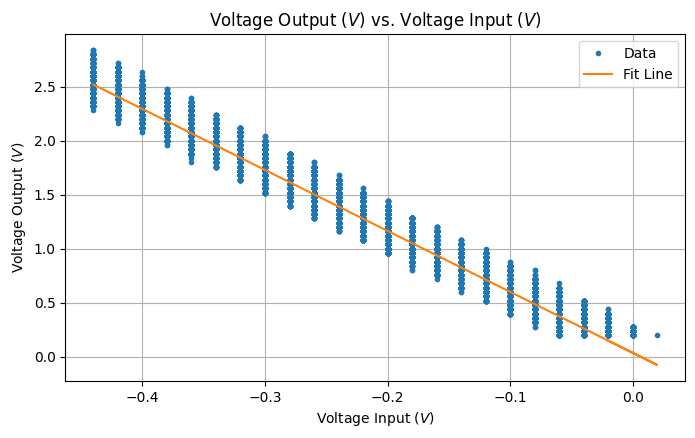

In [53]:
file = open("NL.bin","rb")
file.seek(0x10,0)
temp = file.read(8)
file.seek(0x20,0)
temp1 = file.read(8)
voltdiv = struct.unpack('<d',temp)[0]
vdiv2 = struct.unpack('<d',temp1)[0]
file.seek(0x800,0)
x = np.fromfile(file,dtype=np.uint8)
x = np.int8(x-128)
x,y = np.split(x,2)
x = (x)*(voltdiv/25)*10
x = x-np.min(x)
y = y*(vdiv2/25)
yindices = np.where(y > -0.46)
xindices = np.where(x > 0.2)
indices = np.intersect1d(xindices,yindices)
x = x[indices]
y = y[indices]
p = np.polyfit(y,x,1)
print(p)
fig=plt.figure(figsize=(8,4.5),dpi=100)
plt.plot(y,x,'.')
plt.plot(y, y*p[0] + p[1])
plt.ylabel(r"Voltage Output ($V$)")
plt.xlabel(r"Voltage Input ($V$)")
plt.title(r"Voltage Output ($V$) vs. Voltage Input ($V$)")
plt.legend(["Data", "Fit Line"])
plt.grid()
plt.show()

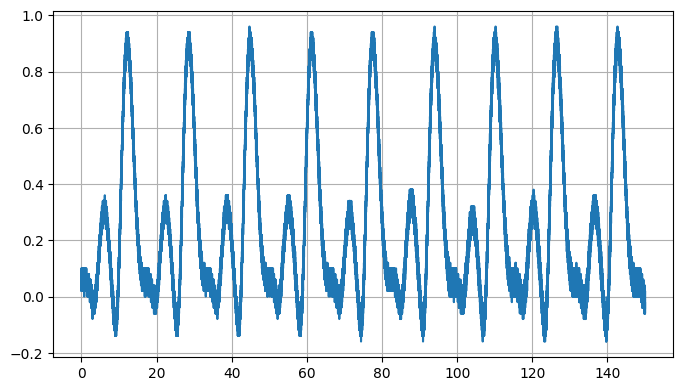

In [2]:
t,xS,dxS = getSol(R/83e3)
file = open("SDS00117.bin","rb")
file.seek(0x10,0)
temp = file.read(8)
voltdiv = struct.unpack('<d',temp)[0]
file.seek(0x800,0)
x = np.fromfile(file,dtype=np.uint8)
x = np.int8(x-128)
x = (x)*(voltdiv/25)*10
fig=plt.figure(figsize=(8,4.5),dpi=100)
plt.plot(np.linspace(0,t[-1],len(x)),x)
# plt.plot(t,xS,'.')
plt.grid()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import struct
file = open("700.bin","rb")
file.seek(0x10,0)
temp = file.read(8)
voltdiv = struct.unpack('<d',temp)[0]
file.seek(0x800,0)
x = np.fromfile(file,dtype=np.uint8)
x = np.int8(x-128)
x = (x)*(voltdiv/25)
fig=plt.figure(figsize=(16,9),dpi=100)
plt.plot(x)
plt.grid()
plt.show()